In [170]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''sklearn'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from patsy import dmatrices

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

# Multiclass
from sklearn.multiclass import OneVsOneClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris

# metrics
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay                         

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression

#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
import tensorflow as tf
from tensorflow import keras
import sys
from copy import deepcopy
# =====================================


In [171]:
path = r'C:\Users\TODO\Desktop\Abhi\AI\AI\allDataSet\KaggelDataset\work\Iris.csv'
df = pd.read_csv(path)
df.columns
df['Species'].value_counts()


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [172]:
X = df.loc[:,['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']].to_numpy()
y = df['Species'].map({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2}).to_numpy()
df['SepalLengthCm'].min(),df['SepalWidthCm'].min(),df['PetalLengthCm'].min(),df['PetalWidthCm'].min()

(4.3, 2.0, 1.0, 0.1)

In [173]:
setosa_or_versicolor = (y == 0) | (y == 1)
setosa_or_versicolor.shape

(150,)

In [174]:
setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]
X.shape

(100, 4)

### Supported vector machine SVC Method by using kernel="linear"

In [175]:
# SVM Classifier model
svm_clf = SVC(kernel="linear", C=1e100)
svm_clf.fit(X, y)

SVC(C=1e+100, kernel='linear')

In [176]:
print('Coff: ',svm_clf.coef_)
print('Int: ',svm_clf.intercept_)
print('Svm Vect: ',svm_clf.support_vectors_)

Coff:  [[ 0.04625854 -0.5211828   1.00304462  0.46412978]]
Int:  [-1.4528445]
Svm Vect:  [[5.1 3.3 1.7 0.5]
 [4.5 2.3 1.3 0.3]
 [5.1 2.5 3.  1.1]]


In [177]:
# Use Linear SVM
X = df.loc[:,['PetalLengthCm','PetalWidthCm']].to_numpy()
y = (df["Species"] == 'Iris-virginica').astype(np.float64)
scalerObj = StandardScaler()
X_scal = scalerObj.fit_transform(X)

### LinearSVC Method with default params

In [178]:
# Linear SVC with default Params
mod = LinearSVC(penalty='l2', 
                loss='squared_hinge',
                tol=0.0001, 
                C=1.0,
                max_iter=1000,
                #Another but importent argument
                multi_class='ovr',   # ???
                fit_intercept=True,  # ???
                intercept_scaling=1, # add const in regressor vevtors
                class_weight=None,   # need to study
                random_state=None    # Frequently use
                )
res = mod.fit(X_scal,y)
res.coef_, res.intercept_
res.predict([[5.5, 1.7]])

array([1.])

### SGDClassifier Method:

using SVC(kernel="linear", C=1), but it is much slower, especially with large training sets, so it is not recommended. 

Qus: So what is alternat method for larg Dataset ?

Use the SGDClassifier class, with SGDClassifier(loss="hinge",alpha=1/(m*C)). 

This applies regular Stochastic Gradient Descent to train a linear SVM classifier. It does not converge as fast as the LinearSVC class, but it can be useful to handle huge datasets that do not fit in memory (out-of-core training), or to handle online classification tasks.

In [179]:
# write code with SGDClassifier

### Create Decisions Boundry


In [180]:
X = df.loc[:,['PetalLengthCm','PetalWidthCm']].to_numpy()
y = df['Species'].map({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2}).to_numpy()

setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]
X.shape, y.shape,X.max(),X.min(),y.max(),y.min()

((100, 2), (100,), 5.1, 0.1, 1, 0)

In [181]:
# SVM Classifier model
svm_clf = SVC(kernel="linear", C=1e100)
res = svm_clf.fit(X, y)
res.coef_,res.coef_[0]

(array([[1.29411744, 0.82352928]]), array([1.29411744, 0.82352928]))

In [182]:
svm_clf.support_vectors_

array([[1.9, 0.4],
       [3. , 1.1]])

In [183]:
# Bad models, Have no idea why this
x0 = np.linspace(0, 5.5, 200)
pred_1 = 5 * x0 - 20
pred_2 = x0 - 1.8
pred_3 = 0.1 * x0 + 0.5

In [184]:
def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    # At the decision boundary, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0] / w[1] * x0 - b / w[1]

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    svs = svm_clf.support_vectors_

    plt.plot(x0, decision_boundary, "k-", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_up, "k--", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_down, "k--", linewidth=2, zorder=-2)
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#AAA',
                zorder=-1)



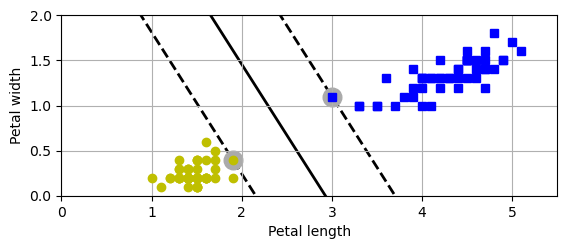

In [185]:
# Set your Graph variable
your_classifications = svm_clf
Xmin = 0
Xmax = 5.5
YCatFirst = 0
YCatSecond = 1
Xregressor = X
Ydependent = y
Xlbl = 'Petal length'
Ylbl = 'Petal width'

plot_svc_decision_boundary(your_classifications, Xmin, Xmax)
plt.plot(Xregressor[:, 0][Ydependent==YCatSecond], Xregressor[:, 1][Ydependent==YCatSecond], "bs")
plt.plot(Xregressor[:, 0][Ydependent==YCatFirst], Xregressor[:, 1][Ydependent==YCatFirst], "yo")
plt.xlabel(Xlbl)
plt.ylabel(Ylbl)
plt.axis([Xmin, Xmax, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()
#save_fig("large_margin_classification_plot")
plt.show()

In [194]:
# Use scalling in classifications
Xs = np.array([[1, 50], [5, 20], [3, 80], [5, 60]]).astype(np.float64)
ys = np.array([0, 0, 1, 1])
std_obj = StandardScaler()
X_scaled = std_obj.fit_transform(Xs)
svm_scaled = SVC(kernel="linear", C=100)
svm_scaled.fit(X_scaled, ys)
X_scaled.min(),X_scaled.max(),

(-1.507556722888818, 1.2701705922171767)

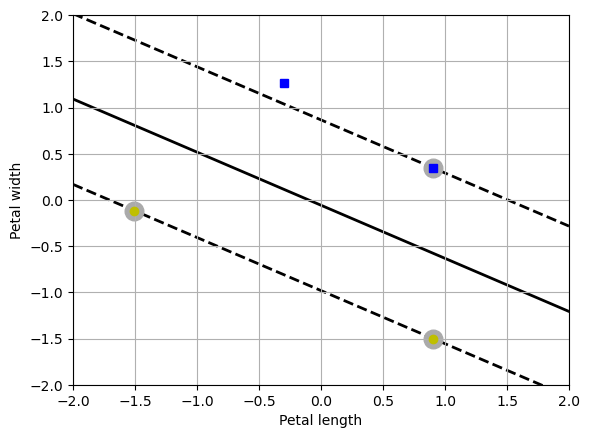

In [197]:
# Set your Graph variable
your_classifications = svm_scaled
Xmin = X_scaled.min()
Xmax = X_scaled.max()
YCatFirst = 0   # available categorical in output
YCatSecond = 1
Xregressor = X_scaled
Ydependent = ys
Xlbl = 'Petal length'
Ylbl = 'Petal width'

plot_svc_decision_boundary(your_classifications, -2, 2)
plt.plot(Xregressor[:, 0][Ydependent==YCatSecond], Xregressor[:, 1][Ydependent==YCatSecond], "bs")
plt.plot(Xregressor[:, 0][Ydependent==YCatFirst], Xregressor[:, 1][Ydependent==YCatFirst], "yo")
plt.xlabel(Xlbl)
plt.ylabel(Ylbl)
plt.axis([-2, 2, -2, 2])
plt.grid()
#save_fig("large_margin_classification_plot")
plt.show()